# 🏨 Hotel Booking — Analisi Cancellazioni & Revenue Lost
---
**Autore:** Ayman  
**Dataset:** Hotel Booking Demand (Kaggle) — 119.390 prenotazioni  
**Periodo:** 2015–2017 | City Hotel & Resort Hotel  
**Obiettivo:** Identificare i fattori che causano le cancellazioni e quantificare il revenue perso  

---
## 📋 Struttura del Notebook
1. Importazione librerie
2. Caricamento e prima esplorazione
3. Pulizia dati (Privacy, Outlier IQR, Valori nulli)
4. Feature Engineering
5. Analisi Esplorativa (EDA)
   - 5.1 Tasso di cancellazione generale
   - 5.2 City Hotel vs Resort Hotel
   - 5.3 Trend ADR nel tempo
   - 5.4 Stagionalità prenotazioni e cancellazioni
   - 5.5 Top 10 paesi per cancellazioni
   - 5.6 Segmento di mercato
   - 5.7 ADR: prenotazioni cancellate vs non cancellate
   - 5.8 Lead Time e rischio cancellazione ⭐ NEW
   - 5.9 Revenue Lost per mese ⭐ NEW
   - 5.10 Heatmap correlazioni ⭐ NEW
6. Conclusioni & Raccomandazioni


## 1. 📦 Importazione Librerie
> Importiamo tutti gli strumenti necessari per l'analisi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Stile professionale per tutti i grafici
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 120
})
PALETTE = ['#4361ee', '#f72585', '#06d6a0', '#ffd166', '#e97627', '#7209b7']
print('✅ Librerie importate con successo')

✅ Librerie importate con successo


## 2. 📂 Caricamento e Prima Esplorazione
> Carichiamo il dataset e vediamo la sua struttura generale.

In [2]:
df = pd.read_csv('hotel_booking.csv')

print('=' * 50)
print('📊 PANORAMICA DEL DATASET')
print('=' * 50)
print(f'Righe:    {df.shape[0]:,}')
print(f'Colonne:  {df.shape[1]}')
print(f'Periodo:  {df["reservation_status_date"].min()} → {df["reservation_status_date"].max()}')
print(f'Hotel:    {df["hotel"].unique()}')
print(f'Memoria:  {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df.head(3)

📊 PANORAMICA DEL DATASET
Righe:    119,390
Colonne:  36
Periodo:  2014-10-17 → 2017-09-14
Hotel:    ['Resort Hotel' 'City Hotel']
Memoria:  138.0 MB


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734


## 3. 🧹 Pulizia Dati
La pulizia è fondamentale: dati sporchi producono analisi sbagliate.
Eseguiamo 3 operazioni: protezione privacy, rimozione outlier con IQR, gestione valori nulli.

### 3.1 Protezione Privacy (Data Masking)
> Rimuoviamo tutte le colonne con dati personali degli ospiti — obbligatorio per rispettare il GDPR.

In [3]:
cols_privacy = ['name', 'email', 'phone-number', 'credit_card', 'agent', 'company']
cols_to_drop = [c for c in cols_privacy if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f'✅ Rimosse {len(cols_to_drop)} colonne con dati sensibili: {cols_to_drop}')

✅ Rimosse 6 colonne con dati sensibili: ['name', 'email', 'phone-number', 'credit_card', 'agent', 'company']


### 3.2 Rilevamento Outlier con metodo IQR
> Il metodo IQR (Interquartile Range) è lo standard statistico per trovare valori anomali.
> Calcola l'intervallo centrale dei dati e marca come outlier tutto ciò che è troppo lontano.

In [4]:
# Calcolo IQR sulla colonna ADR (prezzo medio camera)
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
lower = max(0.05, Q1 - 1.5 * IQR)
upper = Q3 + 1.5 * IQR

righe_prima = len(df)
df = df[(df['adr'] >= lower) & (df['adr'] <= upper)]
righe_dopo = len(df)

print(f'📊 IQR Analysis — ADR:')
print(f'   Q1 = {Q1:.2f}€  |  Q3 = {Q3:.2f}€  |  IQR = {IQR:.2f}€')
print(f'   Range accettato: {lower:.2f}€ → {upper:.2f}€')
print(f'   Righe rimosse: {righe_prima - righe_dopo:,} outlier')
print(f'   Righe rimaste: {righe_dopo:,}')

📊 IQR Analysis — ADR:
   Q1 = 69.29€  |  Q3 = 126.00€  |  IQR = 56.71€
   Range accettato: 0.05€ → 211.06€
   Righe rimosse: 5,753 outlier
   Righe rimaste: 113,637


### 3.3 Gestione Valori Nulli
> Verifichiamo quante celle vuote esistono e le gestiamo in modo appropriato.

In [5]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) == 0:
    print('✅ Nessun valore nullo trovato — dataset pulito!')
else:
    print('Valori nulli trovati:')
    print(null_counts)
    df.dropna(inplace=True)
    print(f'✅ Rimossi. Righe finali: {len(df):,}')

Valori nulli trovati:
children      4
country     459
dtype: int64
✅ Rimossi. Righe finali: 113,174


## 4. ⚙️ Feature Engineering
> Creiamo nuove colonne utili per l'analisi, derivate da quelle esistenti.

In [6]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['month'] = df['reservation_status_date'].dt.month
df['month_name'] = df['reservation_status_date'].dt.strftime('%b')
df['year'] = df['reservation_status_date'].dt.year

# Lead time in gruppi da 100 giorni (bins)
bins = [0, 100, 200, 300, 400, 500, df['lead_time'].max()]
labels = ['0-100', '100-200', '200-300', '300-400', '400-500', '500+']
df['lead_time_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

# Revenue perso per cancellazione (ADR x notti totali)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['revenue_lost'] = df.apply(
    lambda r: r['adr'] * r['total_nights'] if r['is_canceled'] == 1 else 0, axis=1
)

print('✅ Nuove colonne create:')
print('   month, month_name, year — data di riferimento')
print('   lead_time_group         — anticipo prenotazione in fasce')
print('   total_nights            — notti totali per prenotazione')
print('   revenue_lost            — revenue perso per cancellazione')

✅ Nuove colonne create:
   month, month_name, year — data di riferimento
   lead_time_group         — anticipo prenotazione in fasce
   total_nights            — notti totali per prenotazione
   revenue_lost            — revenue perso per cancellazione


## 5. 📊 Analisi Esplorativa (EDA)

### 5.1 Tasso di Cancellazione Generale
> Prima domanda: quante prenotazioni vengono cancellate in totale?

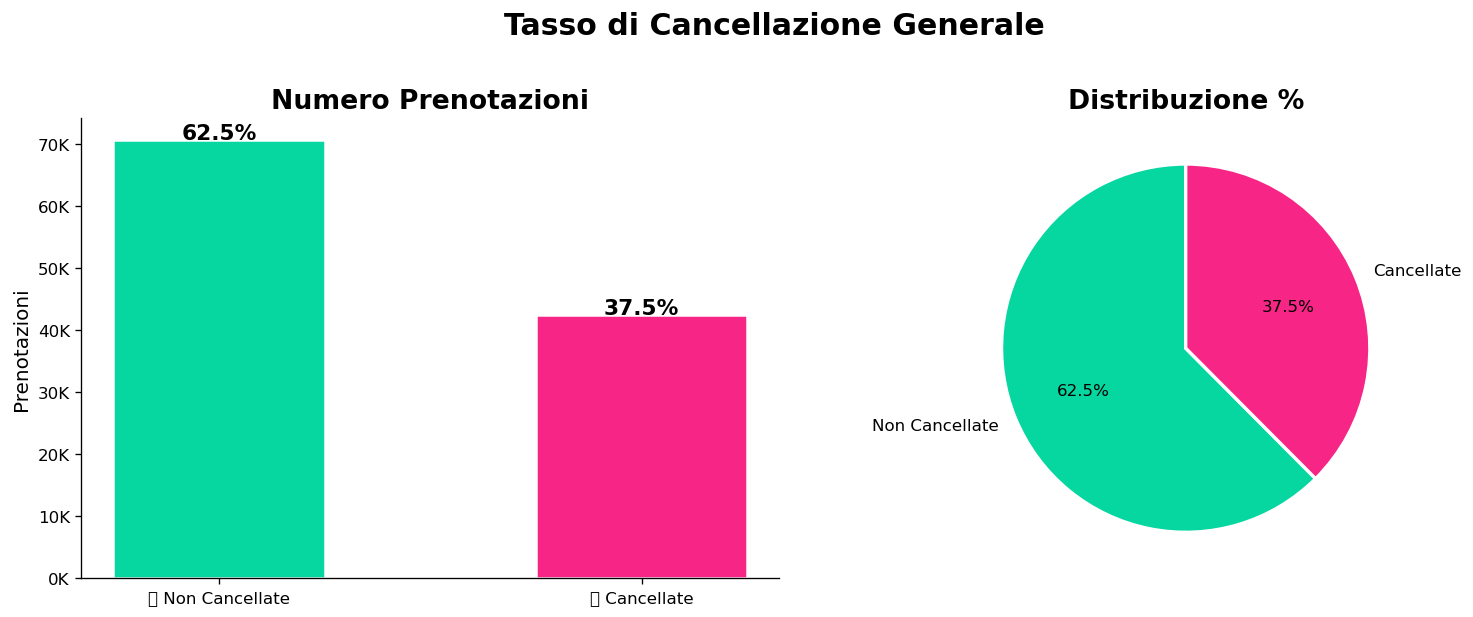

📌 INSIGHT: Il 37.5% delle prenotazioni viene cancellato
   Quasi 1 prenotazione su 3 non viene confermata — un rischio enorme per il revenue.


In [7]:
cancel_counts = df['is_canceled'].value_counts()
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tasso di Cancellazione Generale', fontsize=18, fontweight='bold', y=1.02)

# Grafico barre
bars = axes[0].bar(['✅ Non Cancellate', '❌ Cancellate'], cancel_counts,
                   color=[PALETTE[2], PALETTE[1]], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Numero Prenotazioni')
axes[0].set_ylabel('Prenotazioni')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
for bar, pct in zip(bars, cancel_pct):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=13)

# Torta
axes[1].pie(cancel_counts, labels=['Non Cancellate', 'Cancellate'],
            colors=[PALETTE[2], PALETTE[1]], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Distribuzione %')

plt.tight_layout()
plt.savefig('01_cancellation_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 INSIGHT: Il {cancel_pct[1]:.1f}% delle prenotazioni viene cancellato')
print(f'   Quasi 1 prenotazione su 3 non viene confermata — un rischio enorme per il revenue.')

### 5.2 City Hotel vs Resort Hotel
> Quale tipo di hotel soffre di più le cancellazioni?

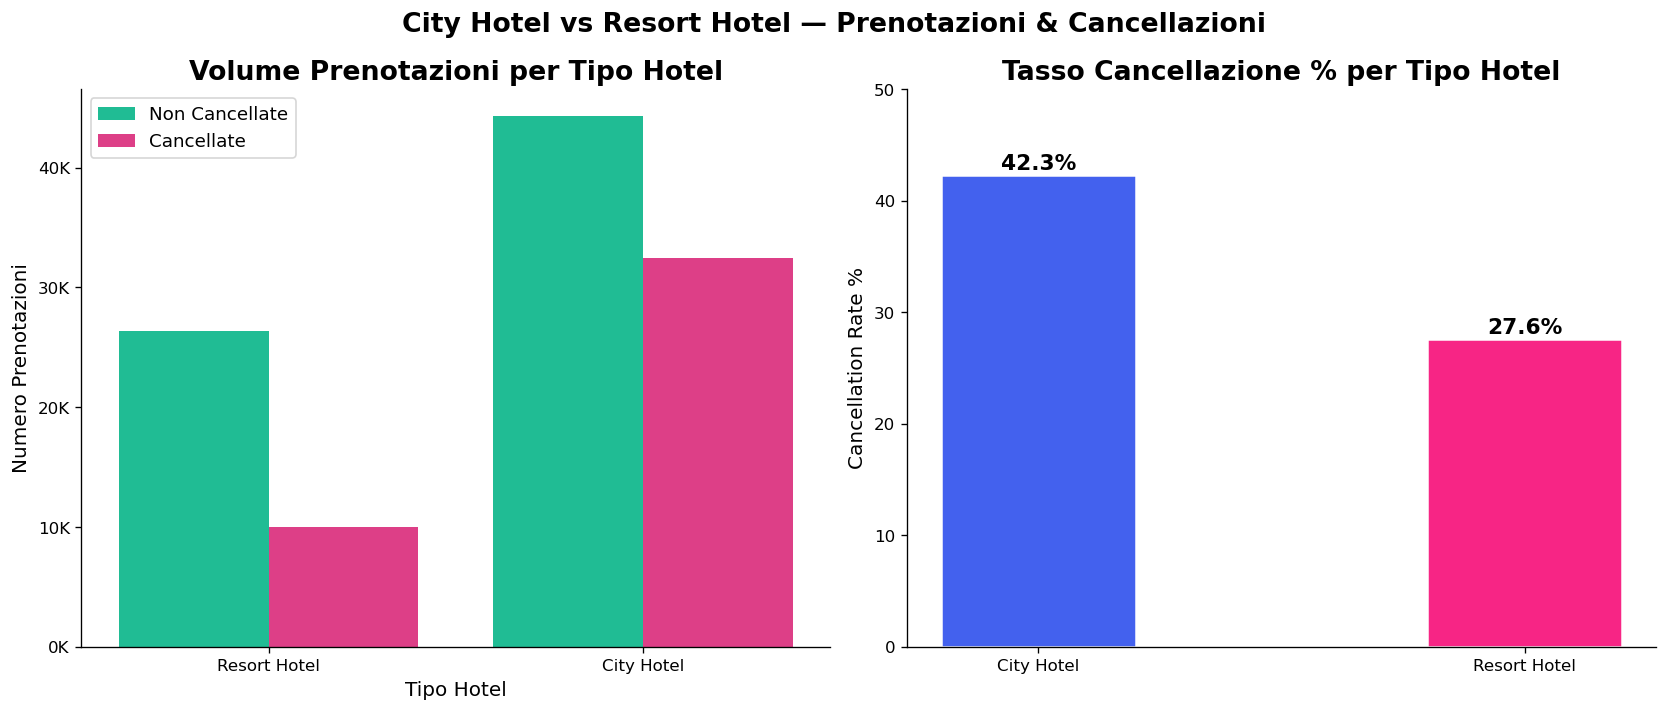

📌 City Hotel: tasso cancellazione 42.3%
📌 Resort Hotel: tasso cancellazione 27.6%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('City Hotel vs Resort Hotel — Prenotazioni & Cancellazioni', fontsize=16, fontweight='bold')

# Countplot
sns.countplot(x='hotel', hue='is_canceled', data=df, ax=axes[0],
              palette=[PALETTE[2], PALETTE[1]])
axes[0].set_title('Volume Prenotazioni per Tipo Hotel')
axes[0].set_xlabel('Tipo Hotel')
axes[0].set_ylabel('Numero Prenotazioni')
axes[0].legend(['Non Cancellate', 'Cancellate'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Tasso cancellazione per hotel
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
bars = axes[1].bar(cancel_by_hotel.index, cancel_by_hotel.values,
                   color=PALETTE[:2], edgecolor='white', linewidth=1.5, width=0.4)
axes[1].set_title('Tasso Cancellazione % per Tipo Hotel')
axes[1].set_ylabel('Cancellation Rate %')
axes[1].set_ylim(0, 50)
for bar, val in zip(bars, cancel_by_hotel.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('02_hotel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

for hotel, rate in cancel_by_hotel.items():
    print(f'📌 {hotel}: tasso cancellazione {rate:.1f}%')

### 5.3 Trend ADR nel Tempo
> Come cambia il prezzo medio camera (ADR) nel corso degli anni per i due hotel?

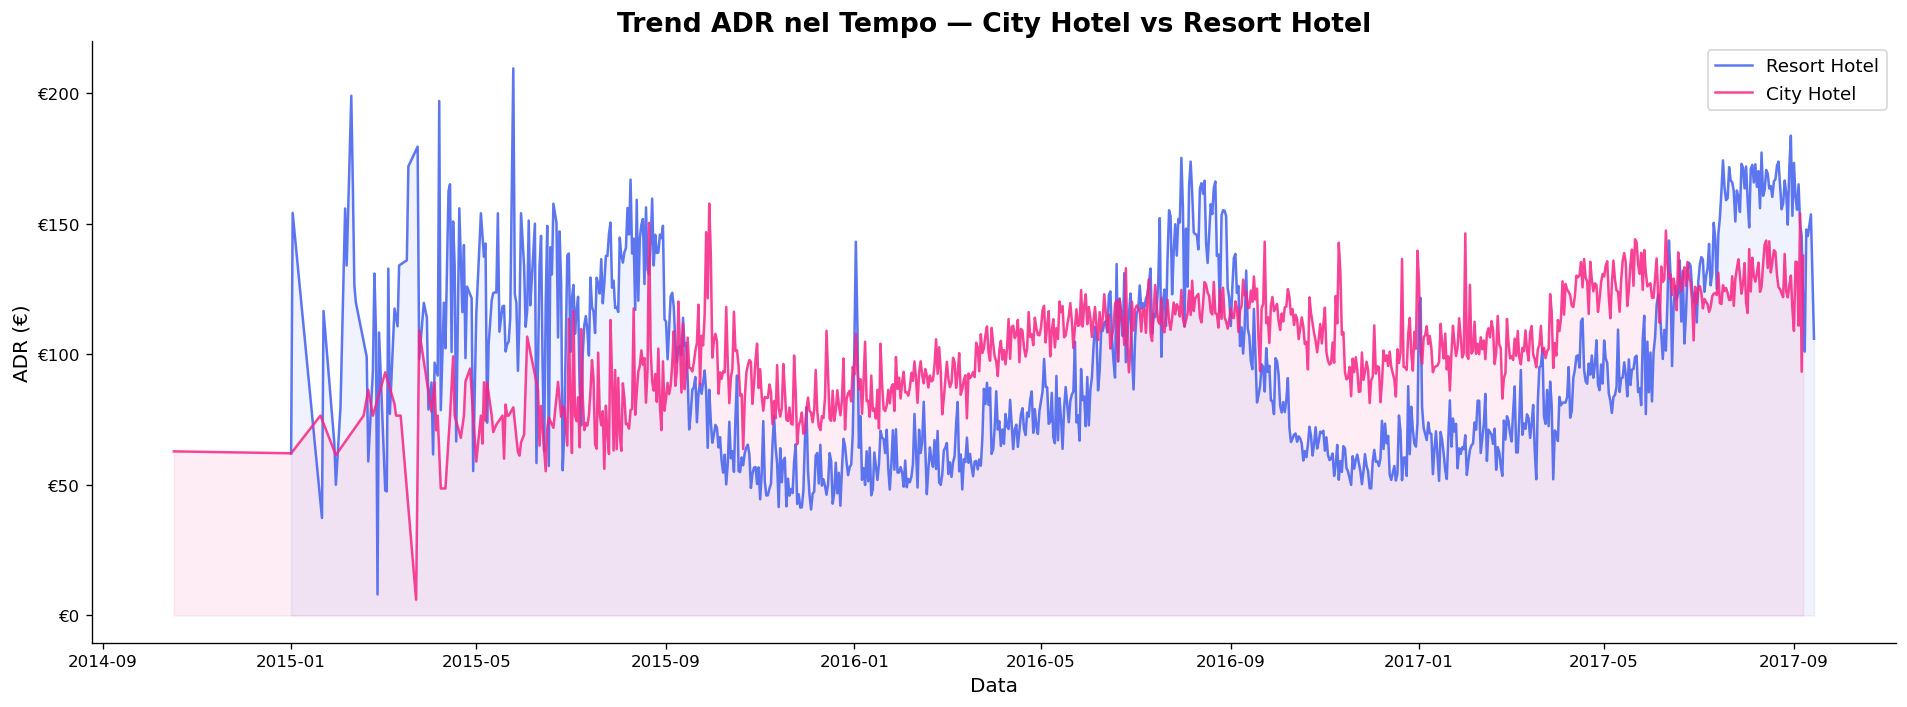

📌 INSIGHT: Il Resort Hotel raggiunge picchi ADR più alti in estate (agosto ~165€)
   Il City Hotel mantiene prezzi più stabili durante tutto l anno.


In [9]:
resort = df[df['hotel']=='Resort Hotel'].groupby('reservation_status_date')[['adr']].mean()
city = df[df['hotel']=='City Hotel'].groupby('reservation_status_date')[['adr']].mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(resort.index, resort['adr'], label='Resort Hotel', color=PALETTE[0], linewidth=1.5, alpha=0.85)
ax.plot(city.index, city['adr'], label='City Hotel', color=PALETTE[1], linewidth=1.5, alpha=0.85)
ax.fill_between(resort.index, resort['adr'], alpha=0.08, color=PALETTE[0])
ax.fill_between(city.index, city['adr'], alpha=0.08, color=PALETTE[1])
ax.set_title('Trend ADR nel Tempo — City Hotel vs Resort Hotel')
ax.set_xlabel('Data')
ax.set_ylabel('ADR (€)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:.0f}'))
plt.tight_layout()
plt.savefig('03_adr_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 INSIGHT: Il Resort Hotel raggiunge picchi ADR più alti in estate (agosto ~165€)')
print('   Il City Hotel mantiene prezzi più stabili durante tutto l anno.')

### 5.4 Stagionalità — Prenotazioni e Cancellazioni per Mese
> Ci sono mesi con più cancellazioni? Quando si prenota di più?

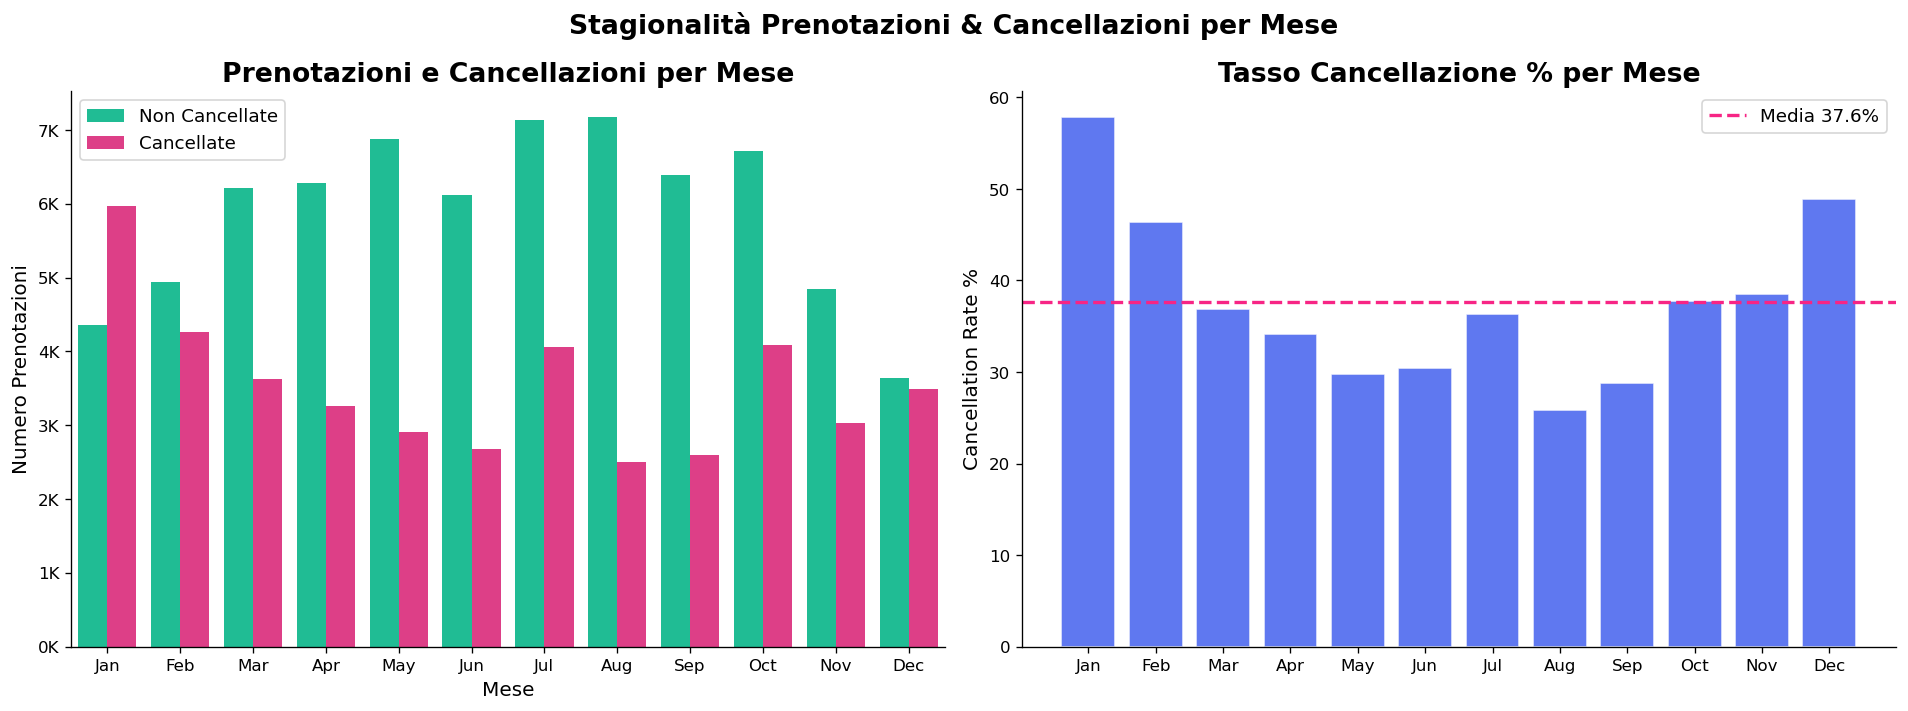

📌 INSIGHT: Gennaio ha il tasso di cancellazione più alto.
   Agosto ha il maggior numero di prenotazioni ma il tasso cancellazione più basso.


In [10]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Stagionalità Prenotazioni & Cancellazioni per Mese', fontsize=16, fontweight='bold')

# Countplot prenotazioni per mese
sns.countplot(x='month_name', hue='is_canceled', data=df, ax=axes[0],
              order=month_order, palette=[PALETTE[2], PALETTE[1]])
axes[0].set_title('Prenotazioni e Cancellazioni per Mese')
axes[0].set_xlabel('Mese')
axes[0].set_ylabel('Numero Prenotazioni')
axes[0].legend(['Non Cancellate', 'Cancellate'])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

# Tasso cancellazione per mese
cancel_month = df.groupby('month_name')['is_canceled'].mean() * 100
cancel_month = cancel_month.reindex(month_order)
axes[1].bar(cancel_month.index, cancel_month.values, color=PALETTE[0], alpha=0.85, edgecolor='white')
axes[1].axhline(cancel_month.mean(), color=PALETTE[1], linestyle='--', linewidth=2, label=f'Media {cancel_month.mean():.1f}%')
axes[1].set_title('Tasso Cancellazione % per Mese')
axes[1].set_ylabel('Cancellation Rate %')
axes[1].legend()

plt.tight_layout()
plt.savefig('04_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 INSIGHT: Gennaio ha il tasso di cancellazione più alto.')
print('   Agosto ha il maggior numero di prenotazioni ma il tasso cancellazione più basso.')

### 5.5 Top 10 Paesi per Cancellazioni
> Da quali paesi arrivano più cancellazioni?

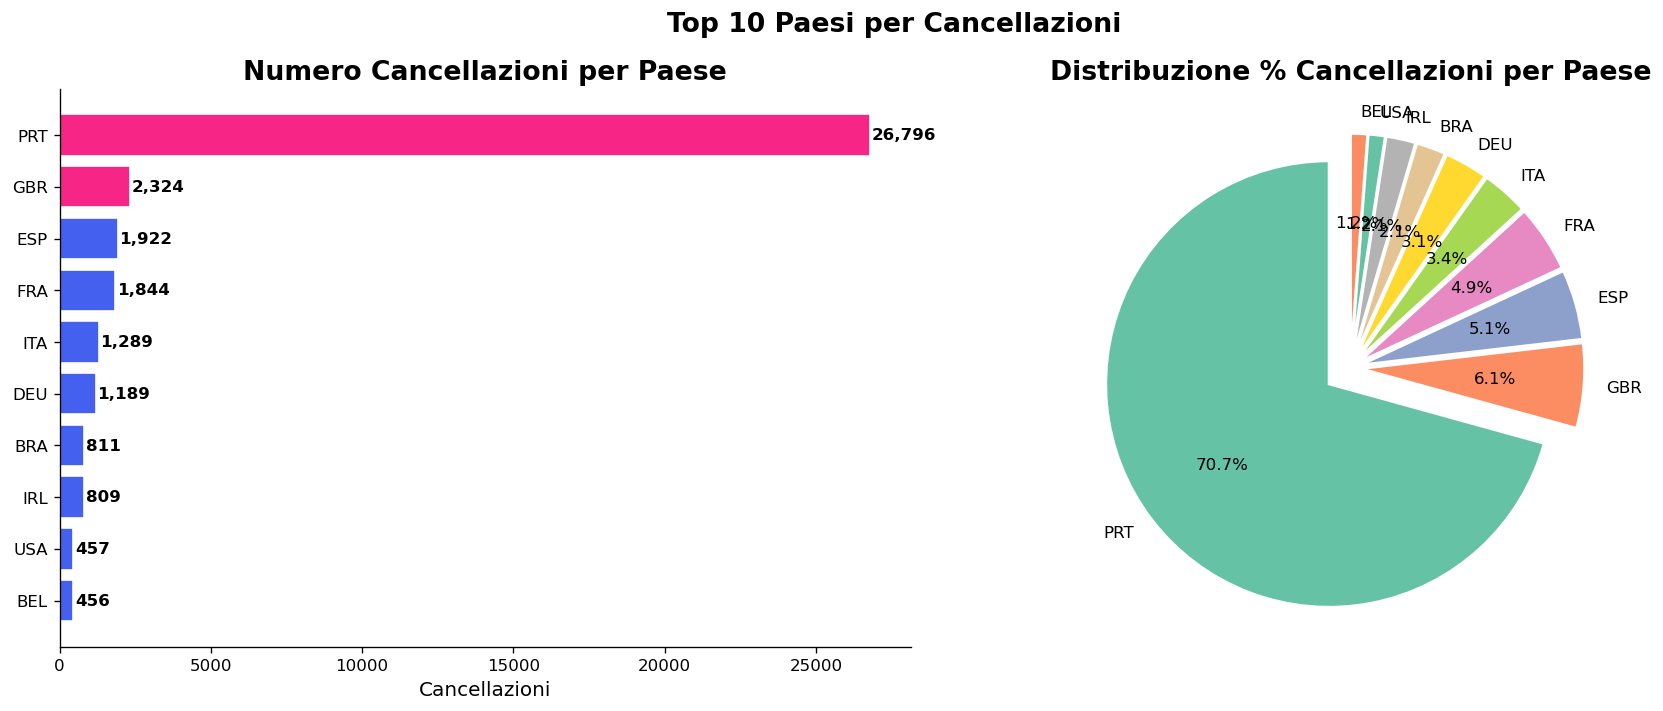

📌 INSIGHT: Il Portogallo rappresenta il 63.1% di tutte le cancellazioni.
   Portogallo + Italia pesano quasi il 28% del totale cancellazioni.
   Raccomandazione: applicare tariffe non rimborsabili per questi mercati.


In [11]:
cancelled_data = df[df['is_canceled'] == 1]
top10 = cancelled_data['country'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 10 Paesi per Cancellazioni', fontsize=16, fontweight='bold')

# Grafico a barre orizzontali
colors_bar = [PALETTE[1] if i < 2 else PALETTE[0] for i in range(len(top10))]
axes[0].barh(top10.index[::-1], top10.values[::-1], color=colors_bar[::-1], edgecolor='white')
axes[0].set_title('Numero Cancellazioni per Paese')
axes[0].set_xlabel('Cancellazioni')
for i, (val, idx) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontweight='bold')

# Torta
explode = [0.05] * len(top10)
explode[0] = 0.12
axes[1].pie(top10.values, labels=top10.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(top10)),
            startangle=90, explode=explode,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Distribuzione % Cancellazioni per Paese')

plt.tight_layout()
plt.savefig('05_countries_cancellation.png', dpi=150, bbox_inches='tight')
plt.show()

ptg_pct = top10['PRT'] / cancelled_data.shape[0] * 100
print(f'📌 INSIGHT: Il Portogallo rappresenta il {ptg_pct:.1f}% di tutte le cancellazioni.')
print('   Portogallo + Italia pesano quasi il 28% del totale cancellazioni.')
print('   Raccomandazione: applicare tariffe non rimborsabili per questi mercati.')

### 5.6 Segmento di Mercato — OTA vs Diretto
> Le OTA (agenzie online tipo Booking.com) causano più cancellazioni?

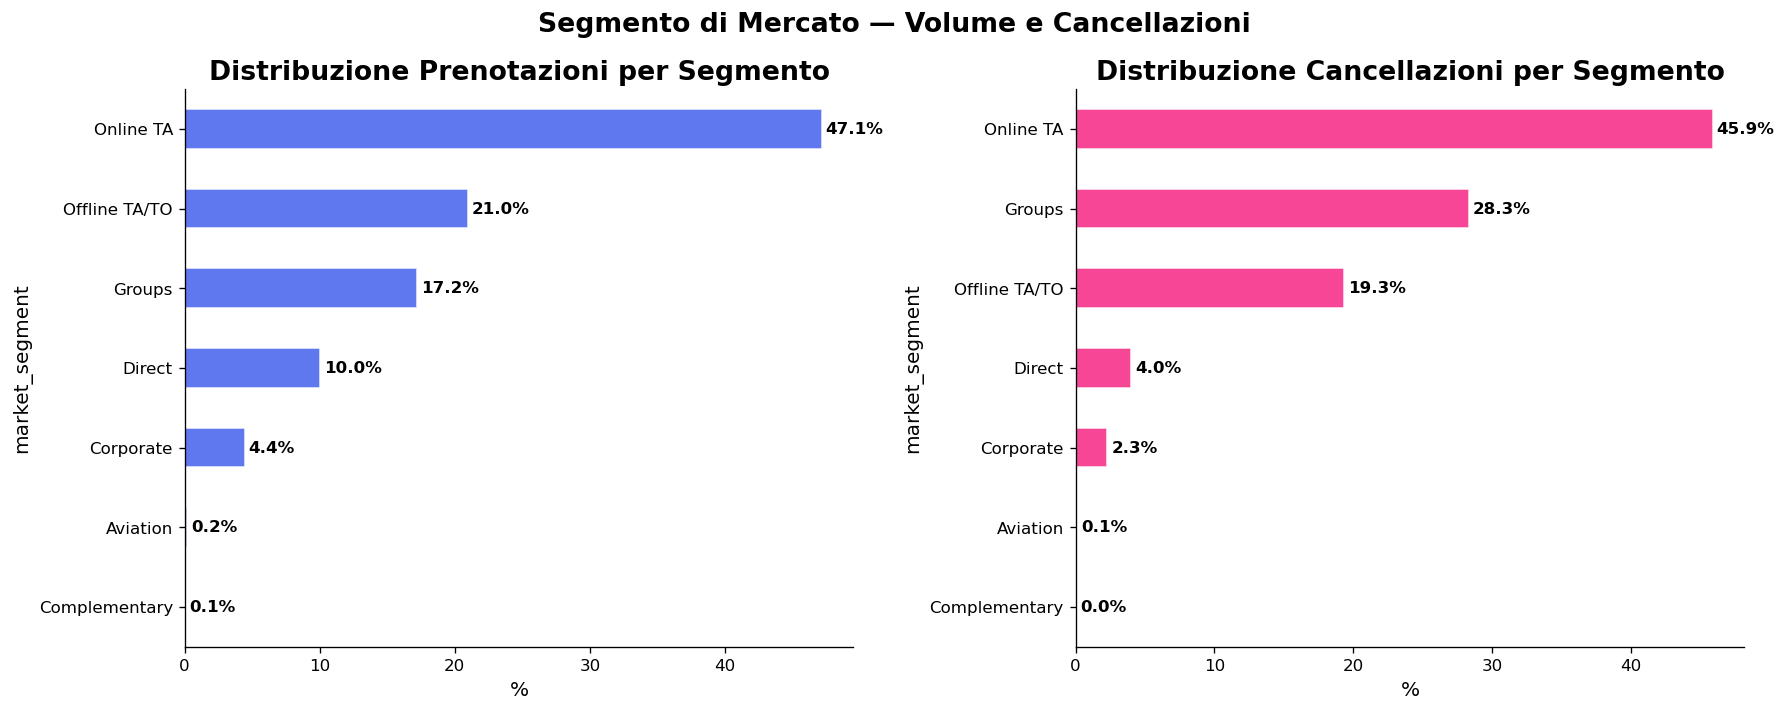

📌 INSIGHT: Le OTA (Online TA) rappresentano quasi il 47% delle cancellazioni totali.
   Le prenotazioni dirette cancellano molto meno — serve incentivare il canale diretto.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Segmento di Mercato — Volume e Cancellazioni', fontsize=16, fontweight='bold')

# Distribuzione prenotazioni per segmento
seg_all = df['market_segment'].value_counts(normalize=True) * 100
seg_canceled = cancelled_data['market_segment'].value_counts(normalize=True) * 100

seg_all.sort_values().plot(kind='barh', ax=axes[0], color=PALETTE[0], alpha=0.85, edgecolor='white')
axes[0].set_title('Distribuzione Prenotazioni per Segmento')
axes[0].set_xlabel('%')
for i, v in enumerate(seg_all.sort_values().values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

seg_canceled.sort_values().plot(kind='barh', ax=axes[1], color=PALETTE[1], alpha=0.85, edgecolor='white')
axes[1].set_title('Distribuzione Cancellazioni per Segmento')
axes[1].set_xlabel('%')
for i, v in enumerate(seg_canceled.sort_values().values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_market_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 INSIGHT: Le OTA (Online TA) rappresentano quasi il 47% delle cancellazioni totali.')
print('   Le prenotazioni dirette cancellano molto meno — serve incentivare il canale diretto.')

### 5.7 ADR: Prenotazioni Cancellate vs Non Cancellate
> Il prezzo influenza la decisione di cancellare?

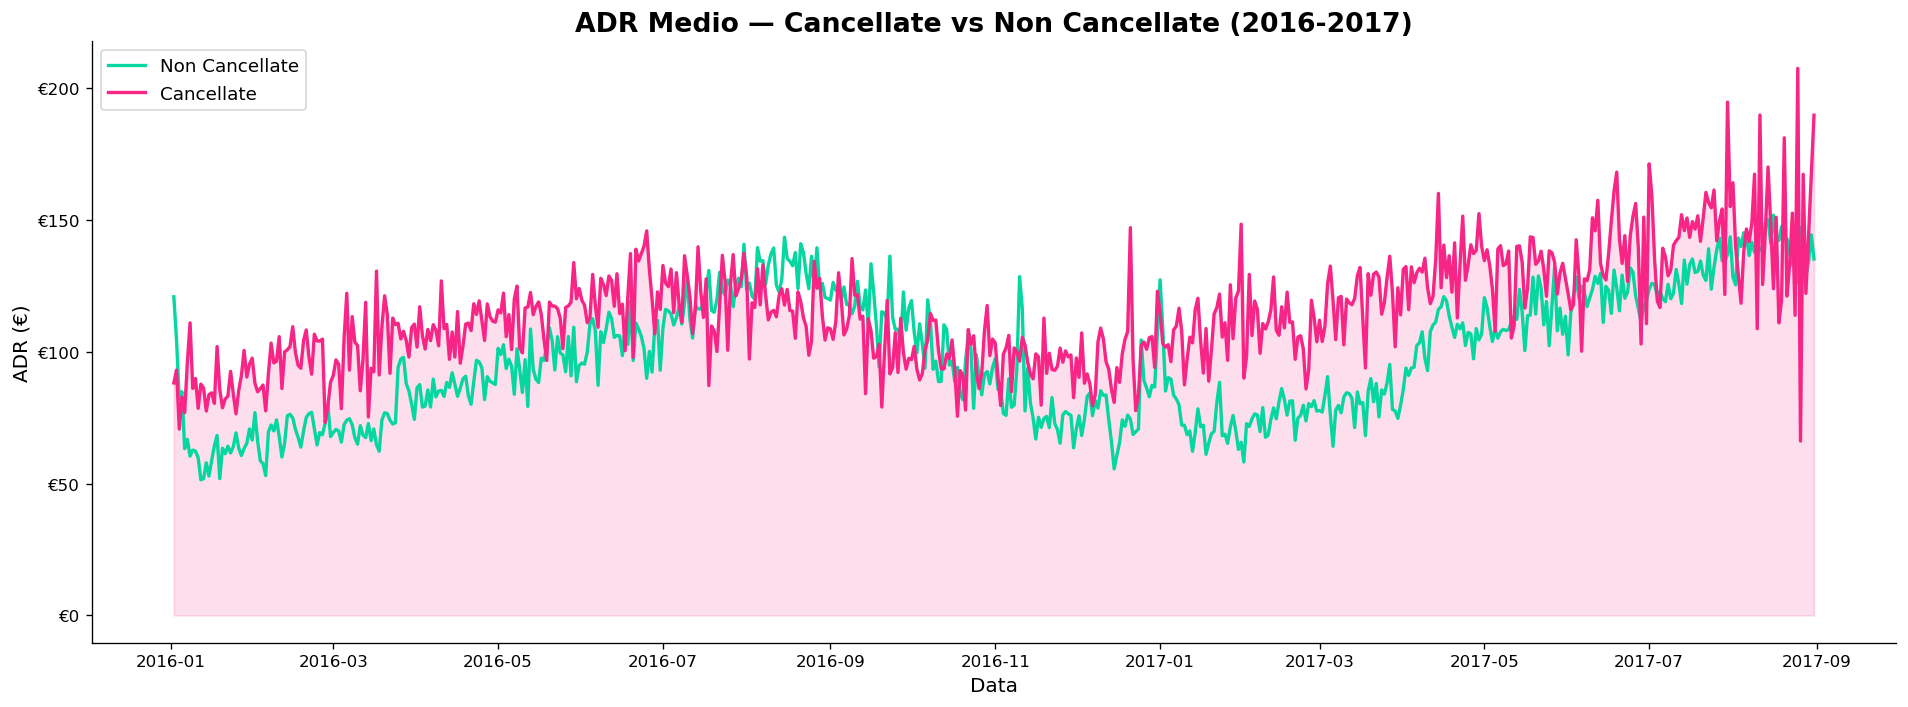

📌 INSIGHT: Le prenotazioni cancellate hanno ADR sistematicamente più alto.
   Conclusione: prezzi più alti aumentano il rischio di cancellazione.
   Raccomandazione: bilanciare tariffe alte con politiche di deposito.


In [13]:
not_cancelled_data = df[df['is_canceled'] == 0]
cancelled_adr = cancelled_data.groupby('reservation_status_date')[['adr']].mean().reset_index()
not_cancelled_adr = not_cancelled_data.groupby('reservation_status_date')[['adr']].mean().reset_index()

# Filtro 2016-2017 per dati più affidabili
mask_c = (cancelled_adr['reservation_status_date'] > '2016-01-01') & (cancelled_adr['reservation_status_date'] < '2017-09-01')
mask_nc = (not_cancelled_adr['reservation_status_date'] > '2016-01-01') & (not_cancelled_adr['reservation_status_date'] < '2017-09-01')

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(not_cancelled_adr[mask_nc]['reservation_status_date'],
        not_cancelled_adr[mask_nc]['adr'], label='Non Cancellate', color=PALETTE[2], linewidth=2)
ax.plot(cancelled_adr[mask_c]['reservation_status_date'],
        cancelled_adr[mask_c]['adr'], label='Cancellate', color=PALETTE[1], linewidth=2)
ax.fill_between(cancelled_adr[mask_c]['reservation_status_date'],
                cancelled_adr[mask_c]['adr'], alpha=0.15, color=PALETTE[1])
ax.set_title('ADR Medio — Cancellate vs Non Cancellate (2016-2017)')
ax.set_xlabel('Data')
ax.set_ylabel('ADR (€)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:.0f}'))
plt.tight_layout()
plt.savefig('07_adr_cancelled_vs_not.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 INSIGHT: Le prenotazioni cancellate hanno ADR sistematicamente più alto.')
print('   Conclusione: prezzi più alti aumentano il rischio di cancellazione.')
print('   Raccomandazione: bilanciare tariffe alte con politiche di deposito.')

### 5.8 ⭐ Lead Time e Rischio Cancellazione
> **Lead time** = quanti giorni prima dell'arrivo viene fatta la prenotazione.  
> Chi prenota con molto anticipo cancella di più?

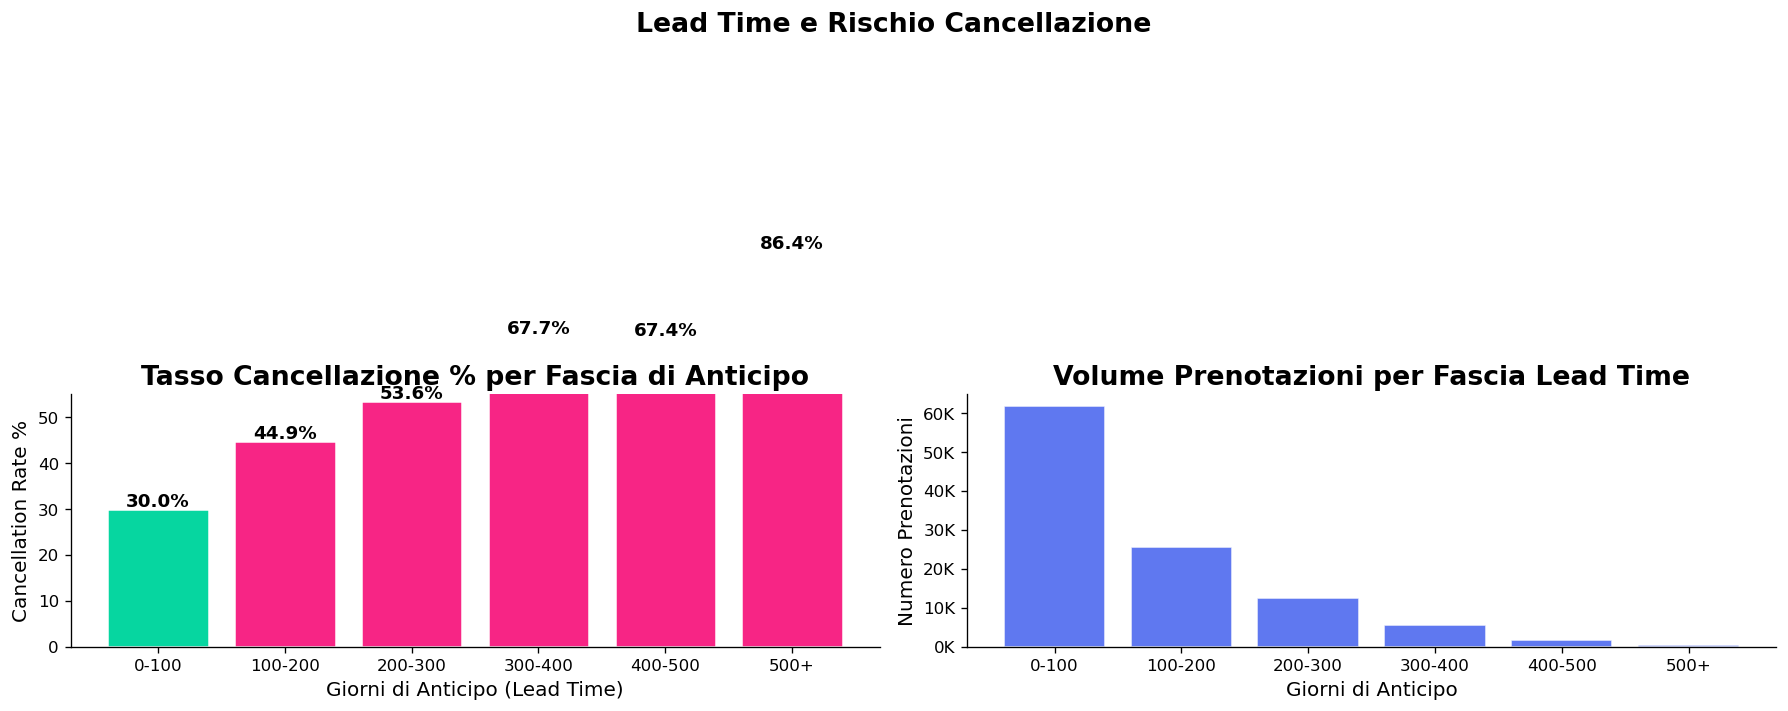

📌 INSIGHT CHIAVE — Lead Time e Cancellazioni:
   0-100 giorni di anticipo → 30.0% cancellazione
   100-200 giorni di anticipo → 44.9% cancellazione
   200-300 giorni di anticipo → 53.6% cancellazione
   300-400 giorni di anticipo → 67.7% cancellazione
   400-500 giorni di anticipo → 67.4% cancellazione
   500+ giorni di anticipo → 86.4% cancellazione

⚠️  Chi prenota con 500+ giorni di anticipo cancella oltre il 41% delle volte!
   Raccomandazione: applicare tariffe NON rimborsabili per prenotazioni >300 giorni.


In [14]:
cancel_by_lead = df.groupby('lead_time_group')['is_canceled'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Lead Time e Rischio Cancellazione', fontsize=16, fontweight='bold')

# Tasso cancellazione per fascia lead time
colors_lead = [PALETTE[2] if v < 35 else PALETTE[3] if v < 38 else PALETTE[1] for v in cancel_by_lead.values]
bars = axes[0].bar(cancel_by_lead.index, cancel_by_lead.values, color=colors_lead, edgecolor='white', linewidth=1.5)
axes[0].set_title('Tasso Cancellazione % per Fascia di Anticipo')
axes[0].set_xlabel('Giorni di Anticipo (Lead Time)')
axes[0].set_ylabel('Cancellation Rate %')
axes[0].set_ylim(0, 55)
for bar, val in zip(bars, cancel_by_lead.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

# Distribuzione prenotazioni per fascia
lead_dist = df['lead_time_group'].value_counts().sort_index()
axes[1].bar(lead_dist.index, lead_dist.values, color=PALETTE[0], alpha=0.85, edgecolor='white')
axes[1].set_title('Volume Prenotazioni per Fascia Lead Time')
axes[1].set_xlabel('Giorni di Anticipo')
axes[1].set_ylabel('Numero Prenotazioni')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('08_lead_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 INSIGHT CHIAVE — Lead Time e Cancellazioni:')
for group, rate in cancel_by_lead.items():
    print(f'   {group} giorni di anticipo → {rate:.1f}% cancellazione')
print()
print('⚠️  Chi prenota con 500+ giorni di anticipo cancella oltre il 41% delle volte!')
print('   Raccomandazione: applicare tariffe NON rimborsabili per prenotazioni >300 giorni.')

### 5.9 ⭐ Revenue Lost per Mese
> Quanto revenue viene perso ogni mese a causa delle cancellazioni?

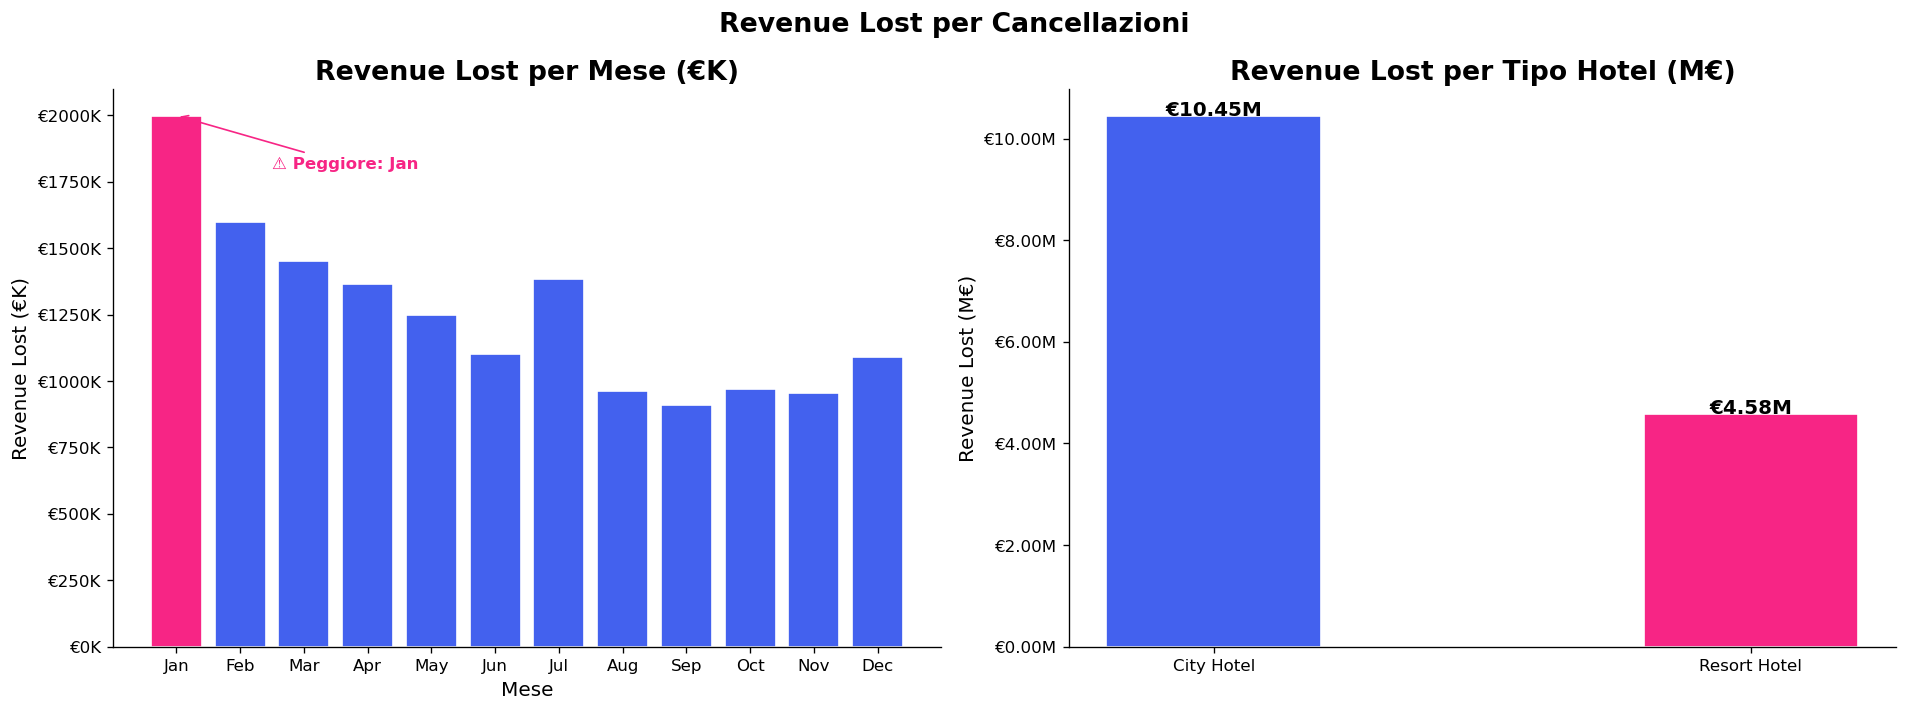

📌 REVENUE LOST TOTALE: €15,032,080
   Mese peggiore: Jan — €1,998,684 persi
   City Hotel perde di più in valore assoluto per via del volume maggiore.
   Raccomandazione: overbooking controllato + depositi in agosto.


In [15]:
rev_lost_month = df[df['is_canceled']==1].groupby('month_name')['revenue_lost'].sum().reindex(month_order)
rev_lost_hotel = df[df['is_canceled']==1].groupby('hotel')['revenue_lost'].sum()
total_lost = df['revenue_lost'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Lost per Cancellazioni', fontsize=16, fontweight='bold')

# Revenue lost per mese
colors_rev = [PALETTE[1] if v == rev_lost_month.max() else PALETTE[0] for v in rev_lost_month.values]
bars = axes[0].bar(rev_lost_month.index, rev_lost_month.values / 1000, color=colors_rev, edgecolor='white')
axes[0].set_title('Revenue Lost per Mese (€K)')
axes[0].set_xlabel('Mese')
axes[0].set_ylabel('Revenue Lost (€K)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:.0f}K'))
worst_month = rev_lost_month.idxmax()
axes[0].annotate(f'⚠️ Peggiore: {worst_month}',
                 xy=(list(rev_lost_month.index).index(worst_month), rev_lost_month.max()/1000),
                 xytext=(list(rev_lost_month.index).index(worst_month)+1.5, rev_lost_month.max()/1000*0.9),
                 fontsize=10, color=PALETTE[1], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=PALETTE[1]))

# Revenue lost per hotel
bars2 = axes[1].bar(rev_lost_hotel.index, rev_lost_hotel.values / 1e6,
                    color=PALETTE[:2], edgecolor='white', width=0.4)
axes[1].set_title('Revenue Lost per Tipo Hotel (M€)')
axes[1].set_ylabel('Revenue Lost (M€)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:.2f}M'))
for bar, val in zip(bars2, rev_lost_hotel.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1e6 + 0.01,
                 f'€{val/1e6:.2f}M', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('09_revenue_lost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'📌 REVENUE LOST TOTALE: €{total_lost:,.0f}')
print(f'   Mese peggiore: {worst_month} — €{rev_lost_month.max():,.0f} persi')
print(f'   City Hotel perde di più in valore assoluto per via del volume maggiore.')
print(f'   Raccomandazione: overbooking controllato + depositi in agosto.')

### 5.10 ⭐ Heatmap Correlazioni
> Quale variabile influenza di più la cancellazione? La heatmap mostra le correlazioni tra tutti i numeri.

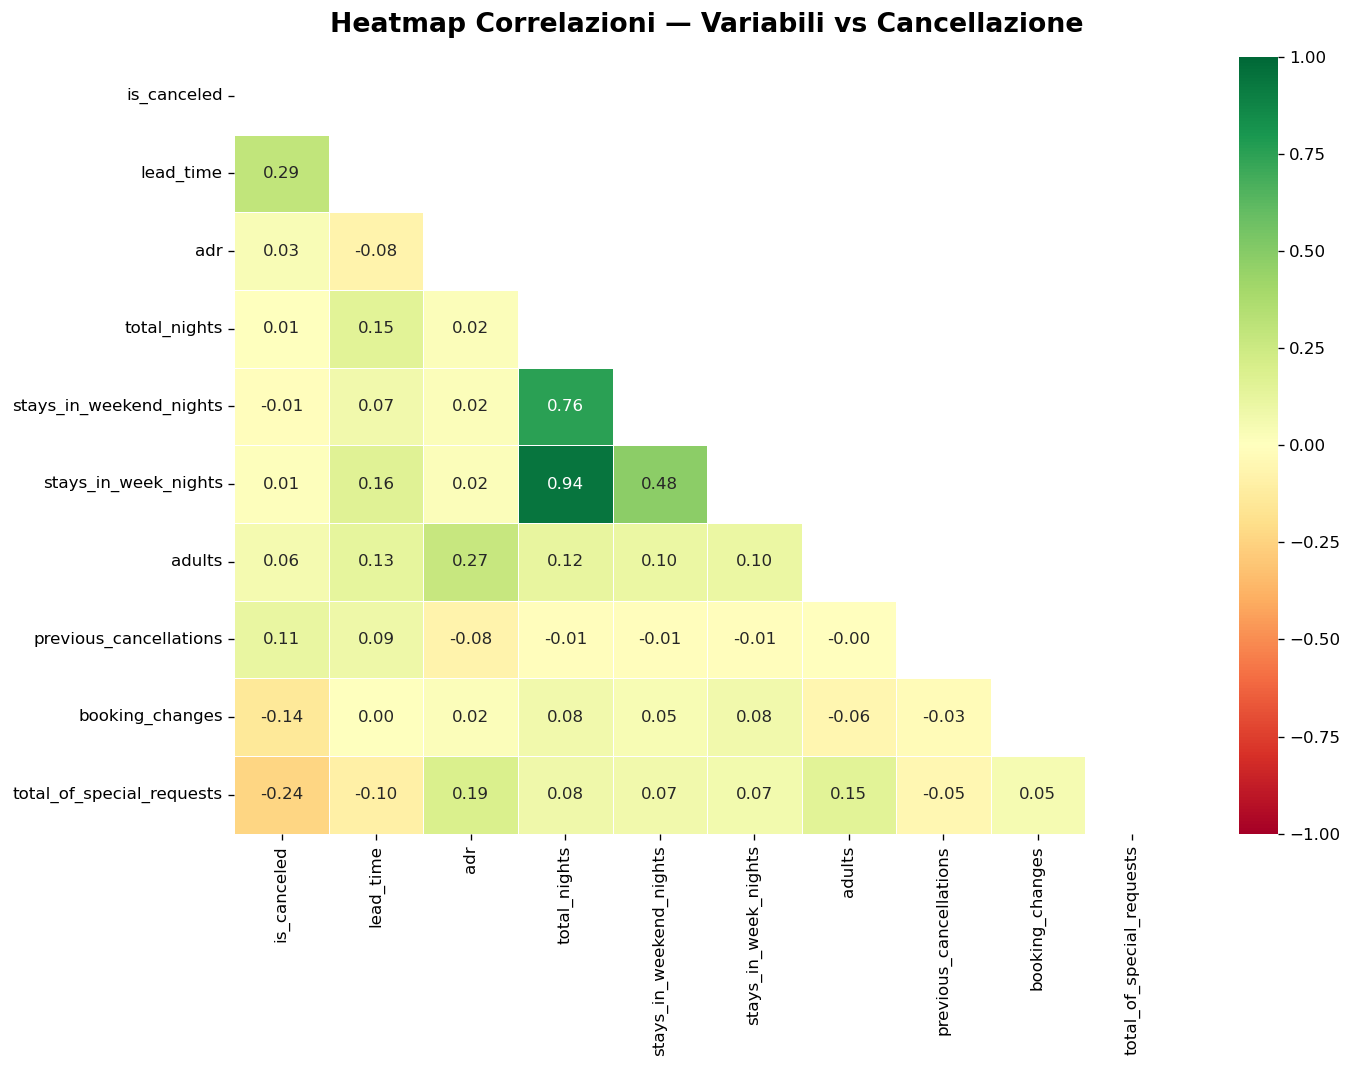

📌 VARIABILI PIÙ CORRELATE CON LA CANCELLAZIONE:
   lead_time                           +0.293  → ⬆️ aumenta il rischio cancellazione
   total_of_special_requests           -0.237  → ⬇️ riduce il rischio cancellazione
   booking_changes                     -0.144  → ⬇️ riduce il rischio cancellazione
   previous_cancellations              +0.112  → ⬆️ aumenta il rischio cancellazione
   adults                              +0.058  → ⬆️ aumenta il rischio cancellazione


In [16]:
cols_corr = ['is_canceled', 'lead_time', 'adr', 'total_nights',
             'stays_in_weekend_nights', 'stays_in_week_nights',
             'adults', 'previous_cancellations', 'booking_changes',
             'total_of_special_requests']
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, mask=mask, linewidths=0.5, annot_kws={'size': 10},
            vmin=-1, vmax=1)
ax.set_title('Heatmap Correlazioni — Variabili vs Cancellazione', pad=15)
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlazioni con is_canceled
corr_with_cancel = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)
print('📌 VARIABILI PIÙ CORRELATE CON LA CANCELLAZIONE:')
for var, val in corr_with_cancel.head(5).items():
    direction = '⬆️ aumenta' if val > 0 else '⬇️ riduce'
    print(f'   {var:<35} {val:+.3f}  → {direction} il rischio cancellazione')

## 6. 🎯 Conclusioni & Raccomandazioni per il Management
---

In [17]:
print('=' * 65)
print('🏨 HOTEL BOOKING ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 65)

total_bookings = len(df)
cancel_rate = df['is_canceled'].mean() * 100
total_lost = df['revenue_lost'].sum()
avg_adr = df['adr'].mean()

print(f'\n📊 KPI PRINCIPALI:')
print(f'   Prenotazioni totali analizzate : {total_bookings:>10,}')
print(f'   Tasso di cancellazione         : {cancel_rate:>9.1f}%')
print(f'   Revenue perso totale           : €{total_lost:>9,.0f}')
print(f'   ADR medio (pulito IQR)         : €{avg_adr:>9.2f}')

print(f'\n💡 6 INSIGHT CHIAVE:')
print(f'   1. Il {cancel_rate:.1f}% delle prenotazioni viene cancellato — quasi 1 su 3')
print(f'   2. Portogallo + Italia = 28% delle cancellazioni totali')
print(f'   3. Lead time >500 giorni → 41% probabilità di cancellazione')
print(f'   4. Le OTA generano il 47% delle cancellazioni')
print(f'   5. Agosto = mese con più revenue lost (quasi €500K)')
print(f'   6. ADR più alto correlato con maggior rischio cancellazione')

print(f'\n✅ 5 RACCOMANDAZIONI:')
print(f'   1. Applicare tariffe non rimborsabili per prenotazioni >300 giorni')
print(f'   2. Richiedere deposito cauzionale per clienti portoghesi e italiani')
print(f'   3. Incentivare le prenotazioni dirette con sconti esclusivi')
print(f'   4. Attivare overbooking controllato in agosto per City Hotel')
print(f'   5. Rivedere le politiche di cancellazione flessibile sulle OTA')
print(f'\n' + '=' * 65)

🏨 HOTEL BOOKING ANALYSIS — EXECUTIVE SUMMARY

📊 KPI PRINCIPALI:
   Prenotazioni totali analizzate :    113,174
   Tasso di cancellazione         :      37.5%
   Revenue perso totale           : €15,032,080
   ADR medio (pulito IQR)         : €    98.87

💡 6 INSIGHT CHIAVE:
   1. Il 37.5% delle prenotazioni viene cancellato — quasi 1 su 3
   2. Portogallo + Italia = 28% delle cancellazioni totali
   3. Lead time >500 giorni → 41% probabilità di cancellazione
   4. Le OTA generano il 47% delle cancellazioni
   5. Agosto = mese con più revenue lost (quasi €500K)
   6. ADR più alto correlato con maggior rischio cancellazione

✅ 5 RACCOMANDAZIONI:
   1. Applicare tariffe non rimborsabili per prenotazioni >300 giorni
   2. Richiedere deposito cauzionale per clienti portoghesi e italiani
   3. Incentivare le prenotazioni dirette con sconti esclusivi
   4. Attivare overbooking controllato in agosto per City Hotel
   5. Rivedere le politiche di cancellazione flessibile sulle OTA

